# Análise Exploratória dos Dados de Segurança do ISP

Nesse notebook faremos uma análise exploratória inicial do nosso dataset. Temos como objetivo final prever a criminalidade em ônibus em cada região com base na série temporal. Vamos, inicialmente, avaliar o conteúdo do dataset, verificar quais colunas podem ser úteis e fazer uma análise geral delas.

## Configurações iniciais do projeto

Importando as bibliotecas e dados

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from faz_mapa import faz_mapa
from IPython.display import IFrame

sequentialpalette = sns.color_palette('inferno')
qualitativepalette = sns.color_palette('colorblind')

sns.set_palette(palette=sequentialpalette)

sns.set_style("whitegrid")

In [3]:
with open("../datasets/dataframe.pkl","rb") as file:
    df = pickle.load(file)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6087 entries, 17389 to 37491
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   cisp                        6087 non-null   int64         
 1   mes                         6087 non-null   int64         
 2   ano                         6087 non-null   int64         
 3   mes_ano                     6087 non-null   datetime64[ns]
 4   aisp                        6087 non-null   int64         
 5   risp                        6087 non-null   int64         
 6   munic                       6087 non-null   object        
 7   mcirc                       6087 non-null   int64         
 8   regiao                      6087 non-null   object        
 9   hom_doloso                  6087 non-null   int64         
 10  lesao_corp_morte            6087 non-null   int64         
 11  latrocinio                  6087 non-null   int64       

O dataset possui MUITAS colunas. A maioria parece não muito relacionada ao nosso problema.

In [5]:
df.isna().sum()

cisp                         0
mes                          0
ano                          0
mes_ano                      0
aisp                         0
                            ..
encontro_ossada              0
pol_militares_mortos_serv    0
pol_civis_mortos_serv        0
registro_ocorrencias         0
fase                         0
Length: 65, dtype: int64

Verificamos que não temos nulos.

Verificando que os dados pegam o histórico de 2014 até 2026.

In [8]:
print(f"Min: {df['ano'].min()}, Max: {df['ano'].max()}")

Min: 2014, Max: 2026


As colunas"roubo_em_coletivo" e "furto_coletivo" dizem respeito a segurança no transporte público, serão usadas por nós.
Além disso, temos os campos "cisp", "aisp" e "risp", que servem de proxy com diferentes níveis de granularidade para as regiões para nas quais os incidentes foram reportados. Podemos ver mais a respeito sobre essas regiões [nesse documento](https://www.ispdados.rj.gov.br/Arquivos/Relacaodas%20RISP_AISP.pdf).

In [27]:
#selecionando colunas
df["crime_coletivo"] = df["roubo_em_coletivo"] + df["furto_coletivo"]
df_coletivo = df[["crime_coletivo","furto_coletivo","roubo_em_coletivo", "cisp"]]

## Exploração de furtos e roubos em coletivos

In [28]:
df_map = df_coletivo.groupby("cisp")["crime_coletivo"].sum().reset_index()
faz_mapa("Crime contra Õnibus Total", "Número de crimes", df_map,["cisp","crime_coletivo"],"cisp")
IFrame(src="./Crime contra Õnibus Total.html", width=700, height=400)

Vemos que a região com mais incidência é a de bonsucesso. Essa região tem o entroncamento entre duas principais vias da cidade (av.brasil e Linha amarela), além de ser cortada pela Linha Vermelha. Ela também abrica o complexo da maré, que fica as margens dessas vias. Nesse sentido, é bem esperado essa ser a região campeã. No entando, os segundo e terceiro lugar serem Barra e Jacarepaguá é surpreendente. Porém esses dados são agregados de um longo período de tempo, precisamos explorar melhor.

### Roubos e furtos em coletivos através do tempo

Vamos valiar a evolução dos roubos e furtos totais ao longo dos anos. Iremos caracterizar por RISPs, que são um nível menos granular que as CISPs, para facilitar a visualização inicialmente.

C:\Users\rhena\AppData\Local\Temp\ipykernel_18920\292458732.py:2: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(data=df, x="ano", y="roubo_em_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)
C:\Users\rhena\AppData\Local\Temp\ipykernel_18920\292458732.py:4: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.barplot(data=df, x="ano", y="furto_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)


<Axes: xlabel='ano', ylabel='furto_coletivo'>

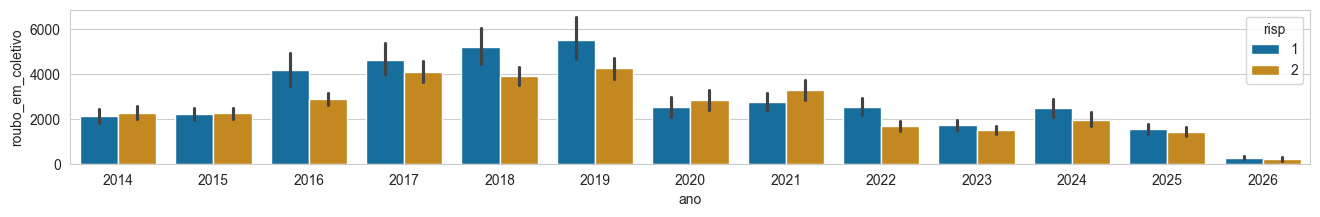

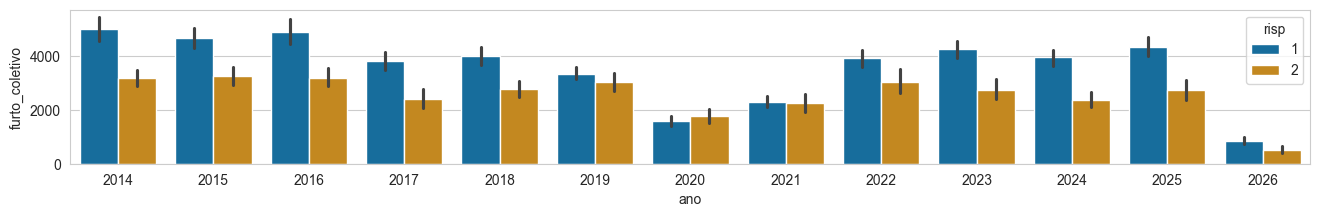

In [19]:
plt.figure(figsize=(16,2))
sns.barplot(data=df, x="ano", y="roubo_em_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)
plt.figure(figsize=(16,2))
sns.barplot(data=df, x="ano", y="furto_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)


Observando os dados através do tempo categorizados por risp, vemos que os roubos em coletivo tiveram um aumento de reportagem em 2016, mas uma queda durante a pandemia, de forma a se estabilizar em valore semelhantes aos anteriores a 2013. Os furtos rapidamente se recuperaram no pós pandemia. Todas as RISPs tiveram evolução semelhante. 
Os anos da pandemia são bem claros no gráfico, e além disso, também percebemos uma evolução diferente entre roubos e furtos! enquanto roubos tiveram uma queda após 2020, os furtos voltaram a subir após a pandemia. Isso indica algum tipo de independência entre essas variáveis!

Vemos que os furtos e roubos em coletivo são uma parte bem pequena dos furtos e roubos totais.

### Buscando correlações entre as colunas
Primeiramente, uma visão geral da correlação

<Axes: >

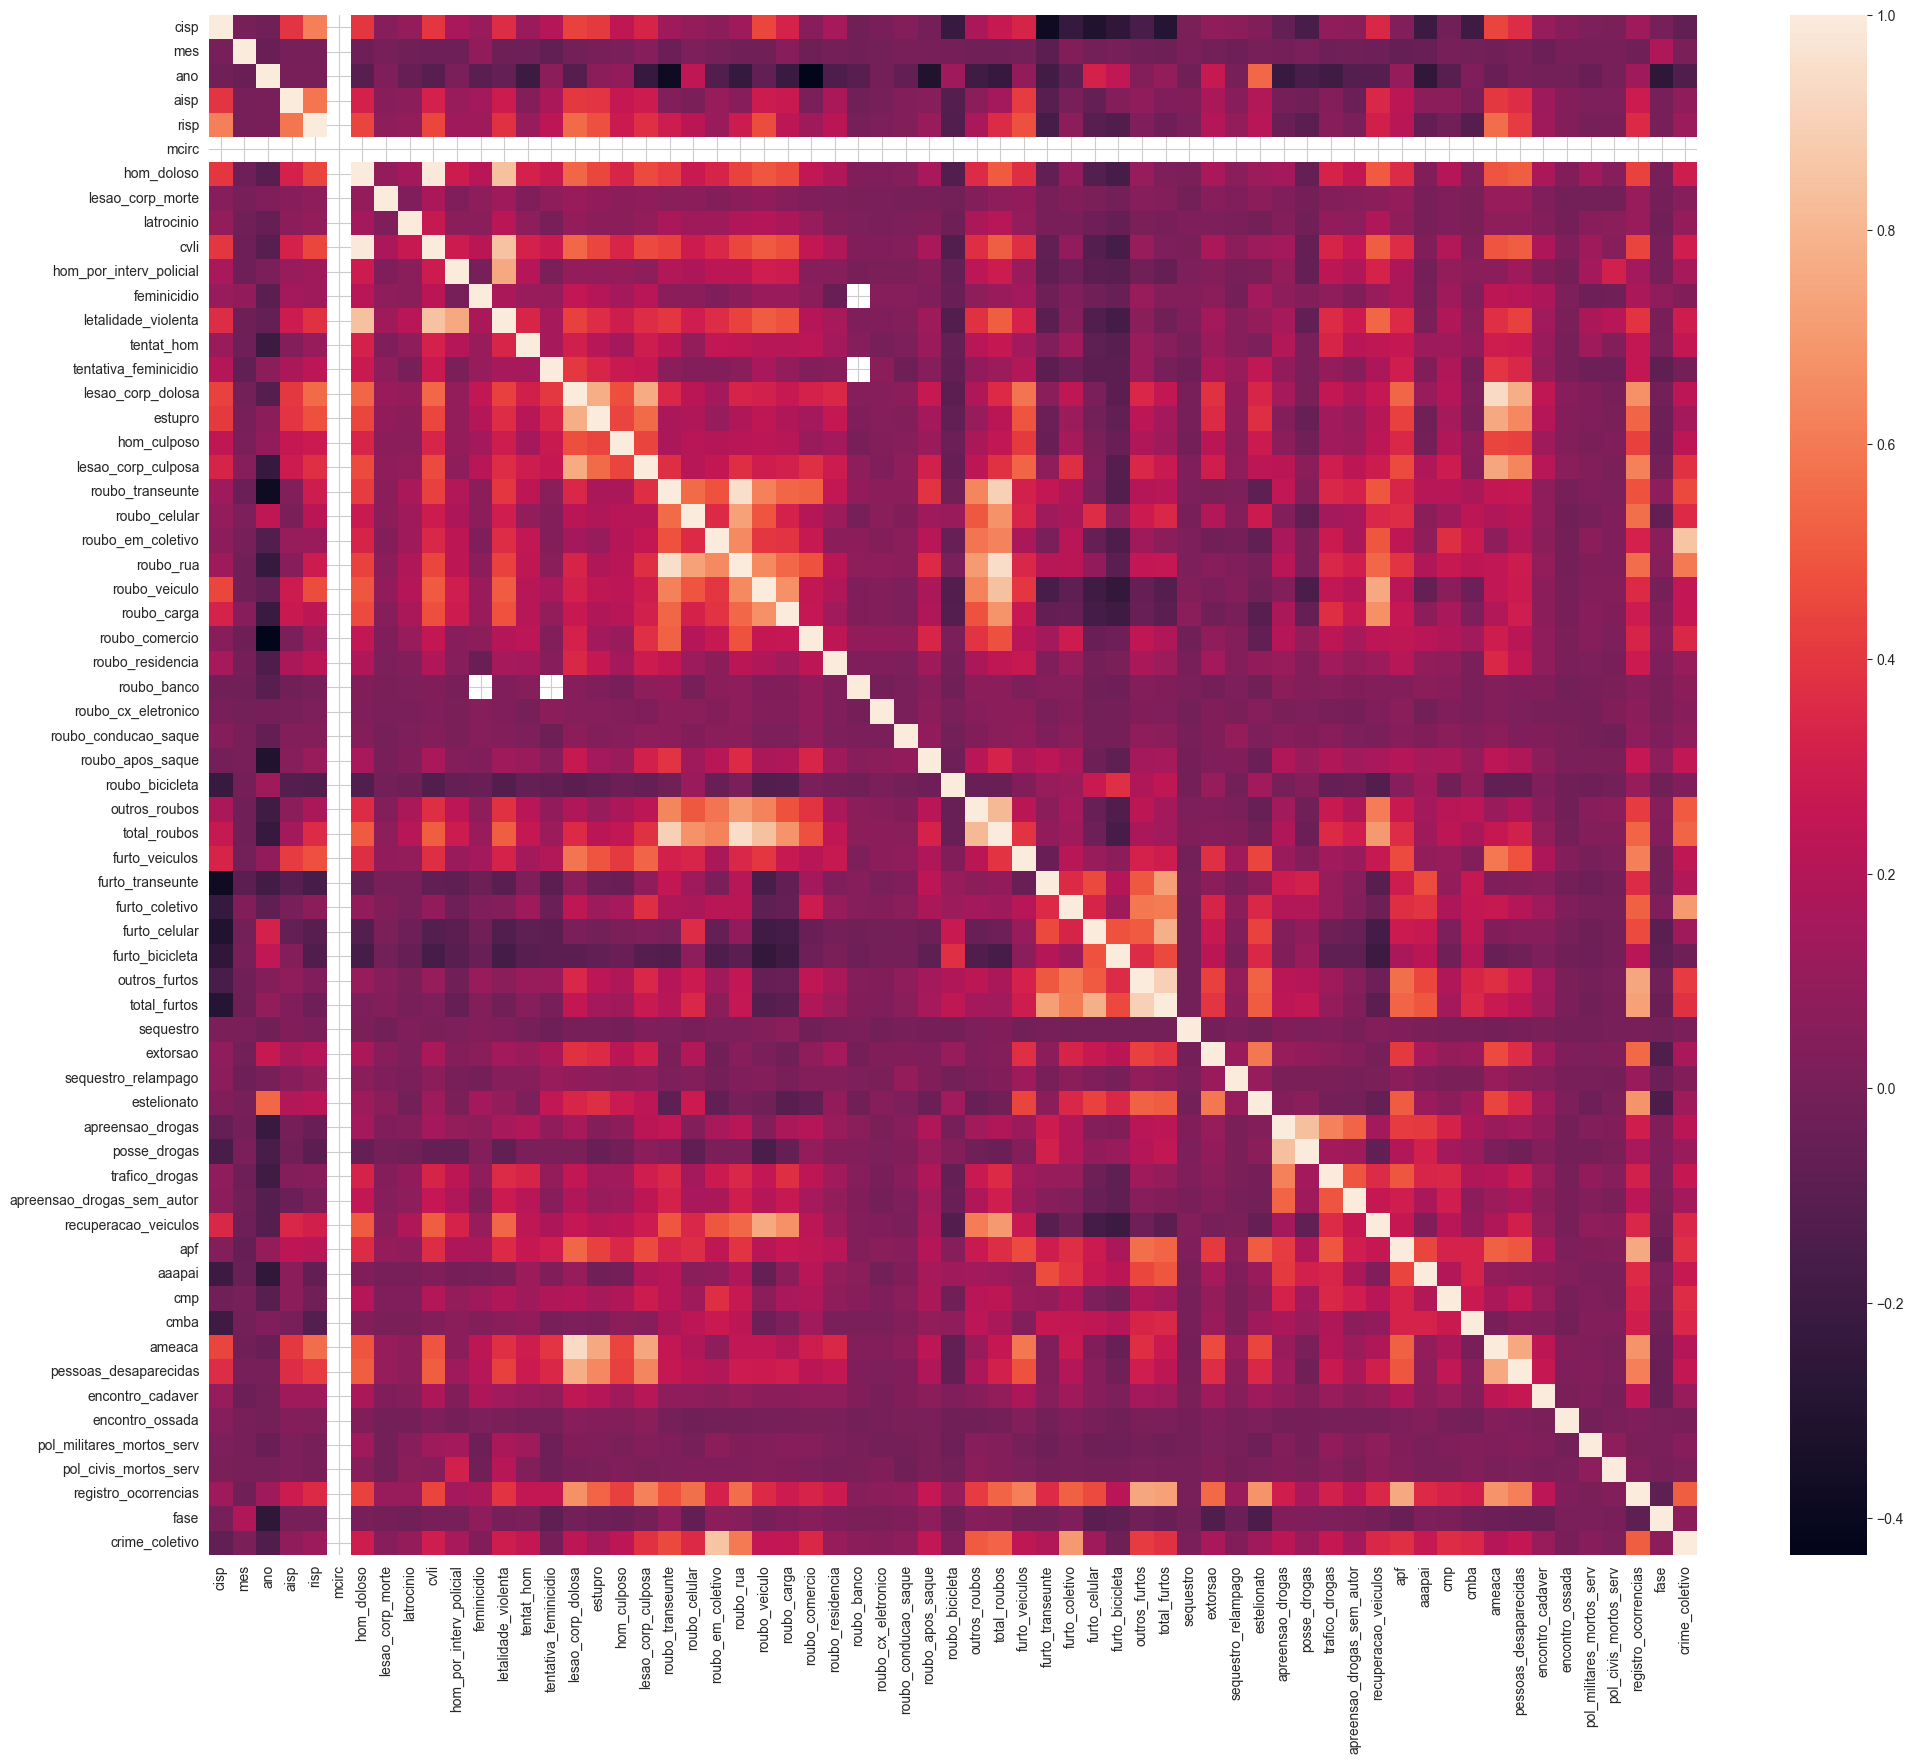

In [20]:
dfnumerical = df.select_dtypes(include=np.number)

plt.figure(figsize=(24,20))
sns.heatmap(dfnumerical.corr())

Se tratam de muitas colunas, fica dificil tirar qualquer conclusão. Selecionando mais delicadamente quais colunas visualizar no heatmap

Text(0.5, 1.0, 'Correlação com Furto em Coletivo > 0.5')

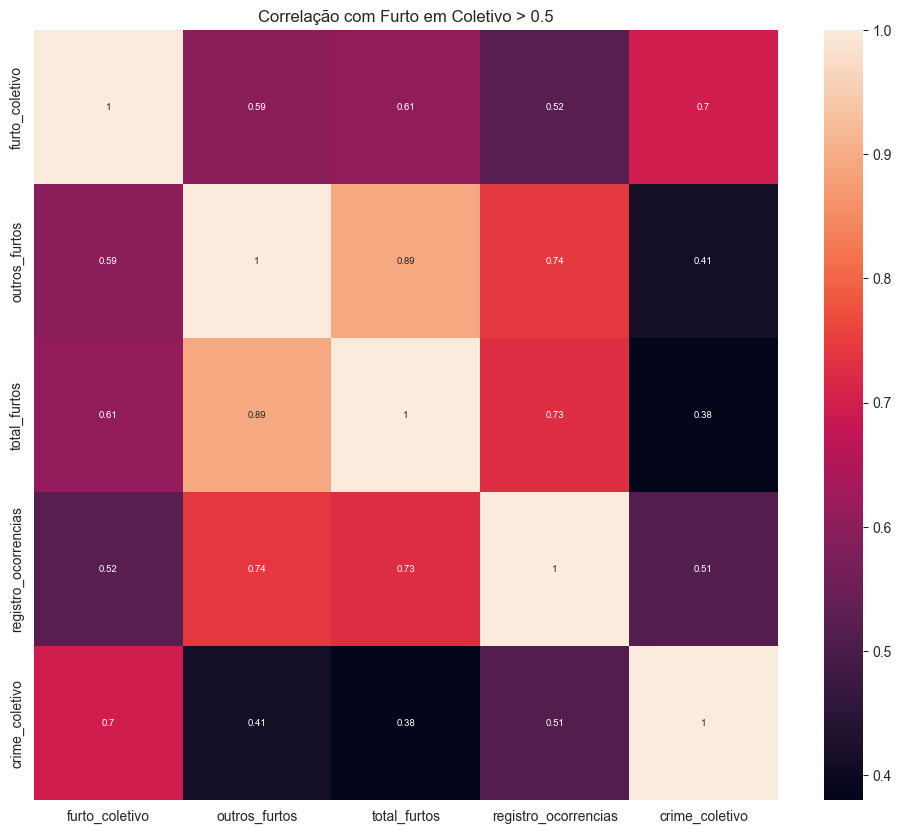

In [24]:
# Fazendo o heatmap somente dos valores que ficam acima de um dado valor (threshold)
threshold = 0.5

dfheatmapcorrfurto = dfnumerical[dfnumerical.corr()[dfnumerical.corr()["furto_coletivo"] > threshold]["furto_coletivo"].keys()].corr()
plt.figure(figsize=(12,10))
sns.heatmap(dfheatmapcorrfurto, annot=True, annot_kws={"size": "x-small"}).set_title(f"Correlação com Furto em Coletivo > {threshold}")

Text(0.5, 1.0, 'Correlação com Roubo em Coletivo > 0.5')

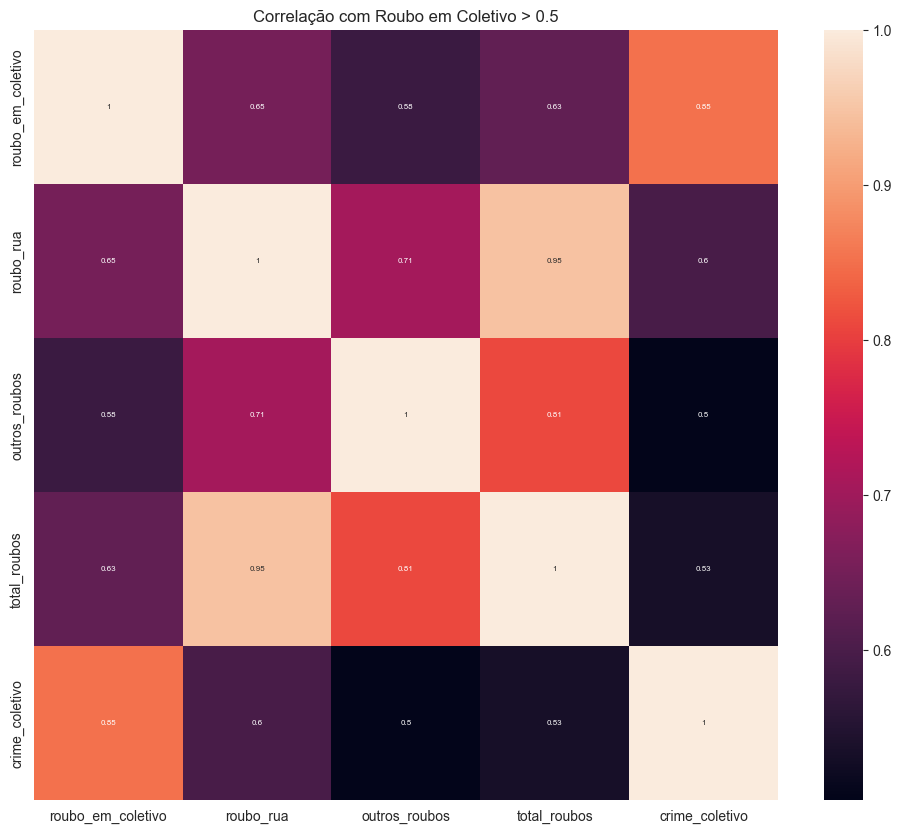

In [25]:
dfheatmapcorrroubo = dfnumerical[dfnumerical.corr()[dfnumerical.corr()["roubo_em_coletivo"] > threshold]["roubo_em_coletivo"].keys()].corr()
plt.figure(figsize=(12,10))
sns.heatmap(dfheatmapcorrroubo, annot=True, annot_kws={"size": "xx-small"}).set_title(f"Correlação com Roubo em Coletivo > {threshold}")

Nesses heatmaps, vemos correlações apenas com crimes da mesma "estirpe": roubo com roubo, furto com furto, a maioria já esperado. O maior insight aqui é que roubos e furtos em coletivos tem baixa correlação entre si! Isso possivelmente indica que se tratem de dois crimes com perfis diferentes. Para avaliar isso, vamos plotar novamente o mapa de crimes, dessa vez separadamente:

In [37]:
df_map = df_coletivo.groupby("cisp")["furto_coletivo"].sum().reset_index()
faz_mapa("Furto contra Õnibus Total", "Número de crimes", df_map,["cisp","furto_coletivo"],"cisp")
IFrame(src="./Furto contra Õnibus Total.html", width=700, height=400)

In [38]:
df_map = df_coletivo.groupby("cisp")["roubo_em_coletivo"].sum().reset_index()
faz_mapa("Roubo contra Õnibus Total", "Número de crimes", df_map,["cisp","roubo_em_coletivo"],"cisp")
IFrame(src="./Roubo contra Õnibus Total.html", width=700, height=400)

AHAAAA! Aqui está nossa grande distinção. Os roubos são crimes explícitos, onde há presença de ameaça e armas de fogo. Esse tipo de crime está prevalencendo nas regiões mais pobres (zona norte, oeste, jacareágua), enquanto o furto, que é quanto se leva um pertence sem ameaça, está com mais força na zona sul e barra. As variáveis realmente são diferentes entre si, e vamos precisar tratá-las de forma separada! Avaliando a evolução dos dois novamente, desta vez sem separar RISPs, podemos confirmar de forma mais clara:

<Axes: xlabel='ano', ylabel='total_furtos'>

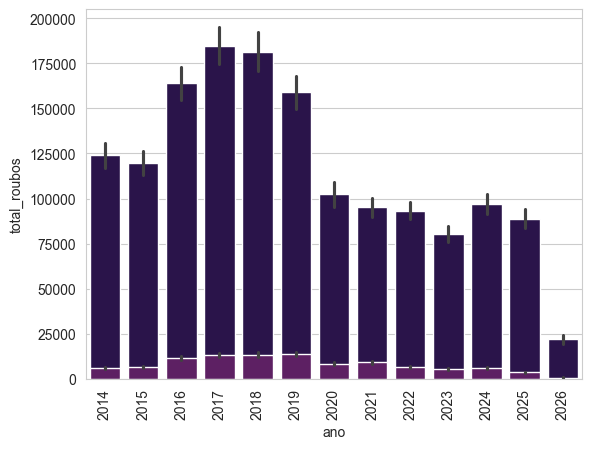

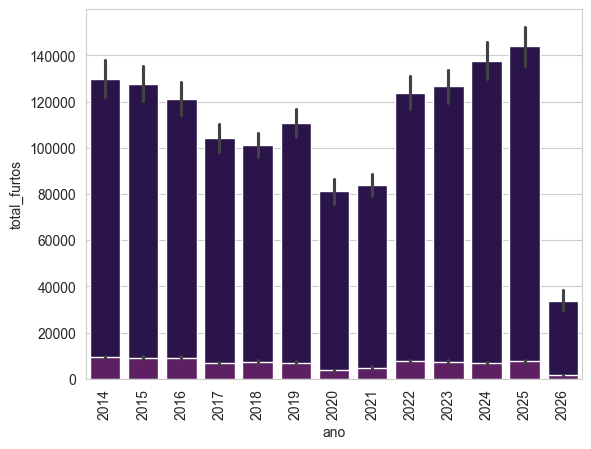

In [ ]:
plt.figure()
plt.xticks(rotation=90)
sns.barplot(data=df, x="ano", y="total_roubos", estimator="sum")
sns.barplot(data=df, x="ano", y="roubo_em_coletivo", estimator="sum")
plt.figure()
plt.xticks(rotation=90)
sns.barplot(data=df, x="ano", y="total_furtos", estimator="sum")
sns.barplot(data=df, x="ano", y="furto_coletivo", estimator="sum")

C:\Users\rhena\AppData\Roaming\Python\Python314\site-packages\seaborn\axisgrid.py:1513: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(x=vector, **plot_kwargs)
C:\Users\rhena\AppData\Roaming\Python\Python314\site-packages\seaborn\axisgrid.py:1513: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(x=vector, **plot_kwargs)
C:\Users\rhena\AppData\Roaming\Python\Python314\site-packages\seaborn\axisgrid.py:1513: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(x=vector, **plot_kwargs)
C:\Users\rhena\AppData\Roaming\Python\Python314\site-packages\seaborn\axisgrid.py:1513: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  func(x=vector, **plot_kwargs)
C:\Users\rhena\AppData\Roaming\Python\Python314\site-packages\seaborn\axisgrid.py:1513: UserWarning: The palette list has more values (10) t

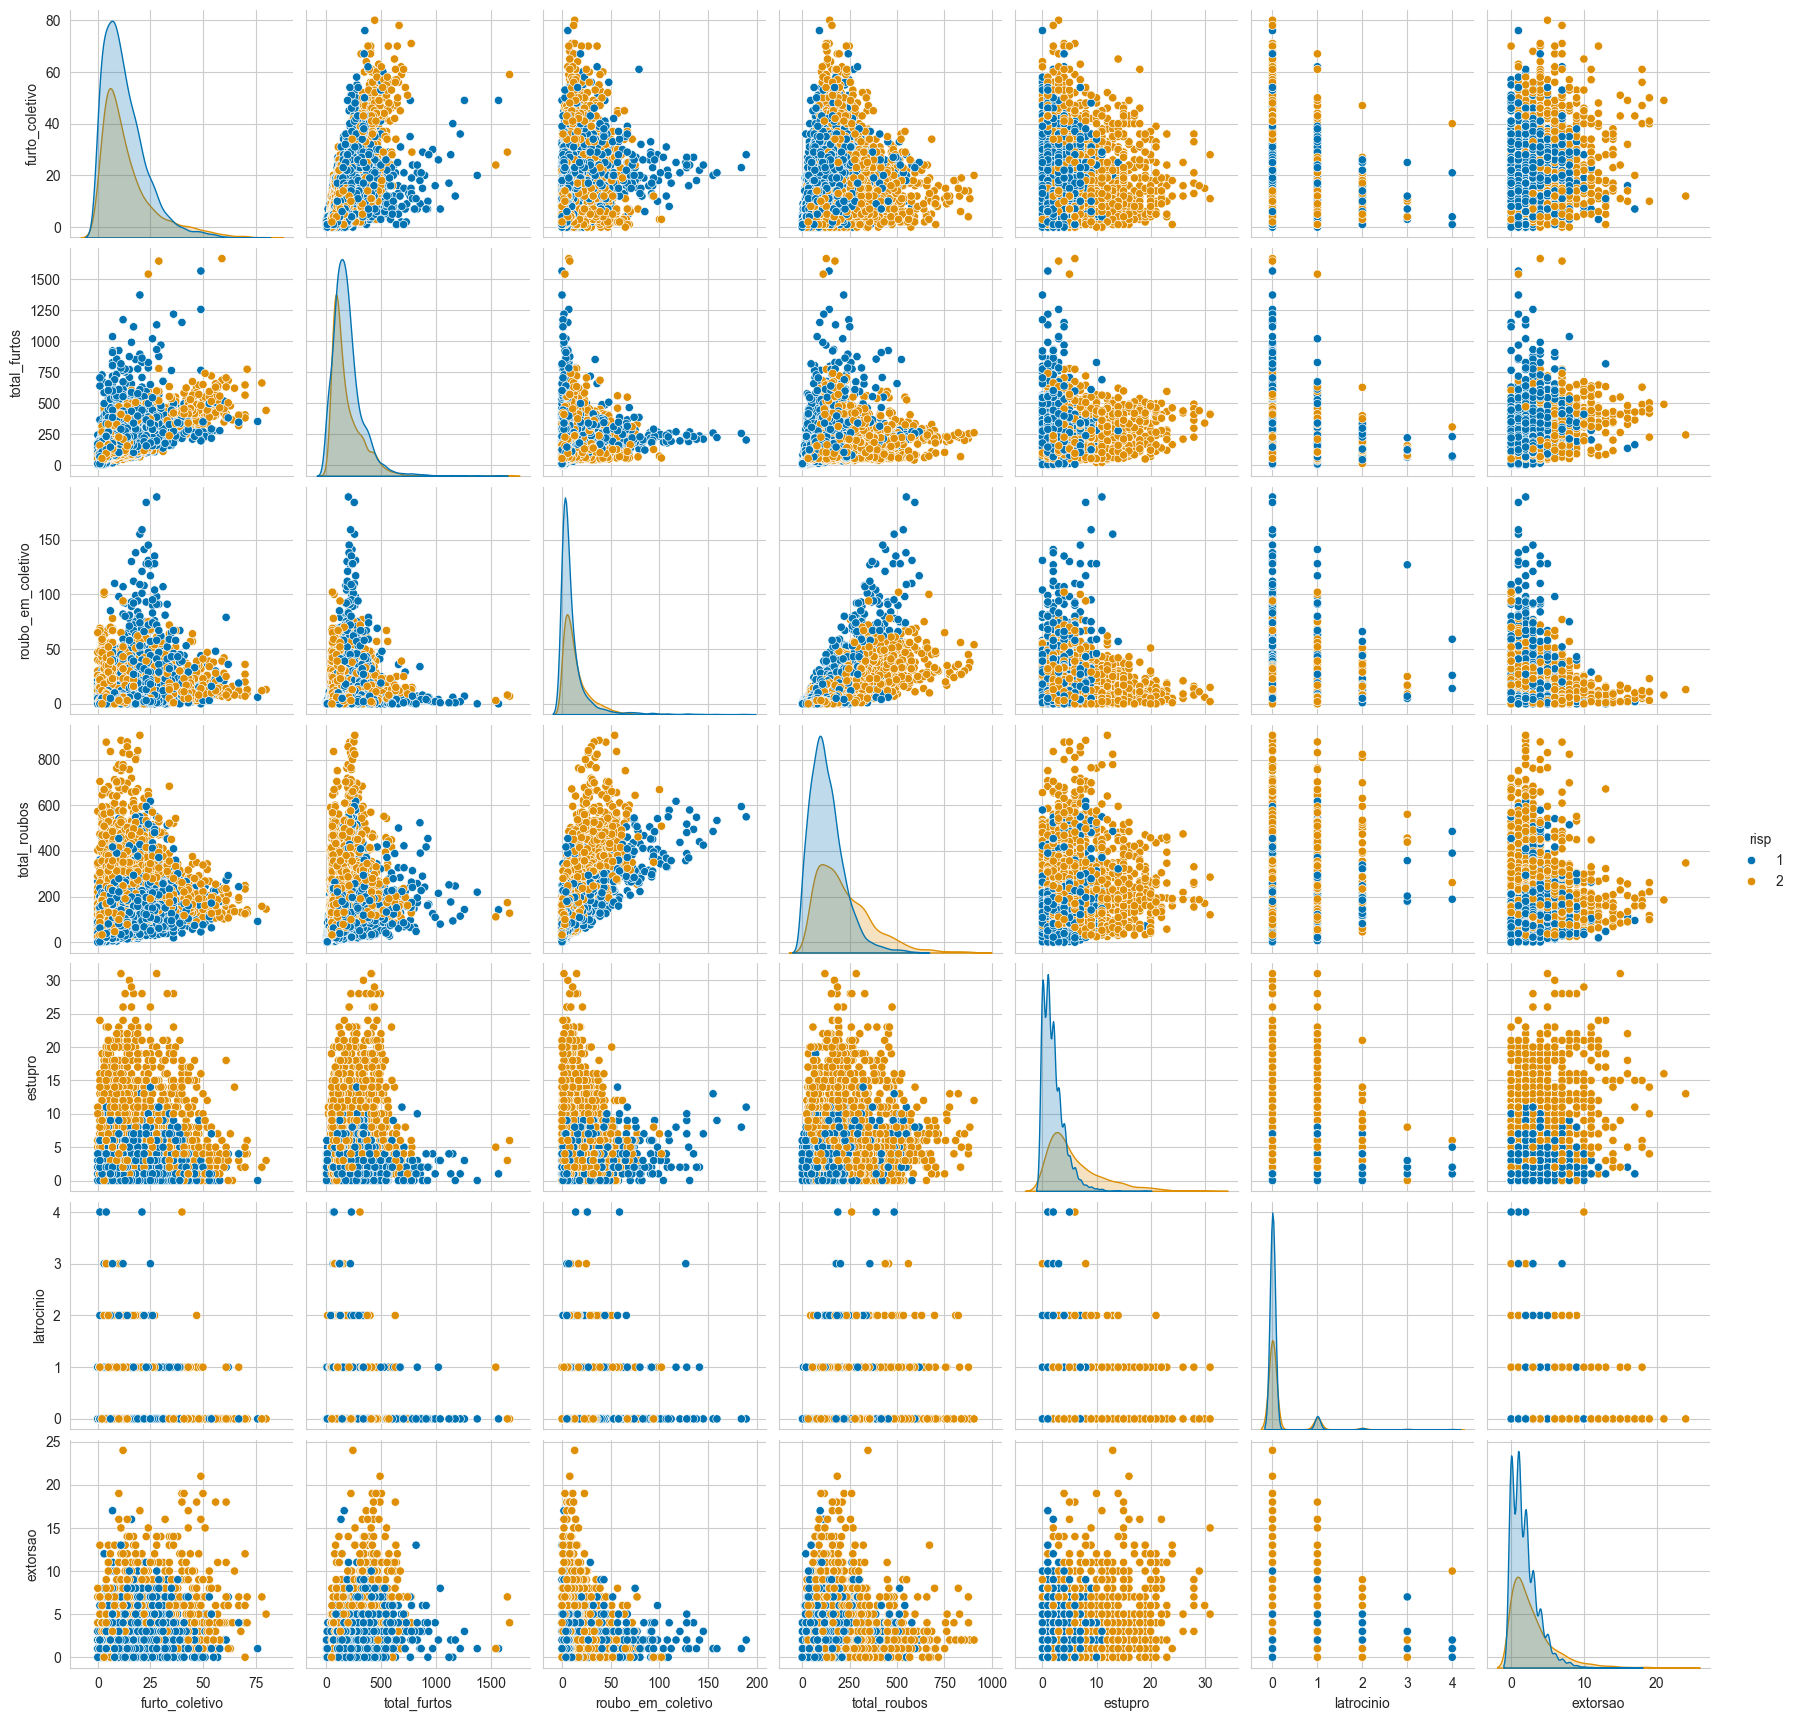

In [36]:
dfpair = df[["furto_coletivo", "total_furtos", 
                "roubo_em_coletivo", "total_roubos",
                "risp",
                "estupro",
                "latrocinio",
                "extorsao"]]

sns.pairplot(dfpair, hue="risp", palette=qualitativepalette) 

# Análise A PARTIR DE 2021

Como tivemos a pandemia em 2020, vamos avaliar o que ocorreu de 2021 para frente, sem considerar essa quebra de sistema:

In [12]:
print(df["ano"].dtype)
df = df[df['ano'] >= 2021]

int64


C:\Users\marce\AppData\Local\Temp\ipykernel_9352\460210649.py:2: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(data=df, x="ano", y="roubo_em_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)
C:\Users\marce\AppData\Local\Temp\ipykernel_9352\460210649.py:4: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(data=df, x="ano", y="furto_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)


<Axes: xlabel='ano', ylabel='furto_coletivo'>

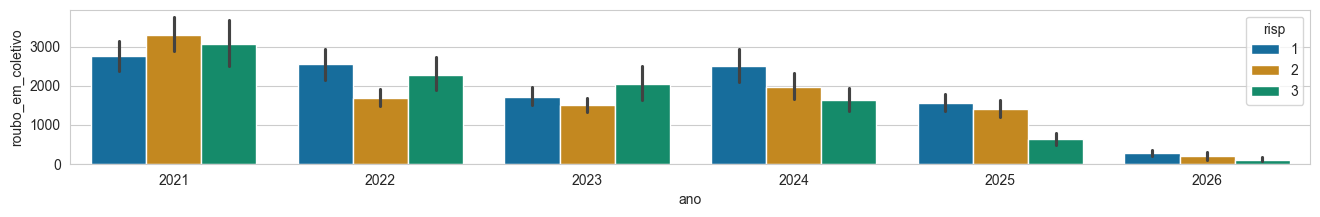

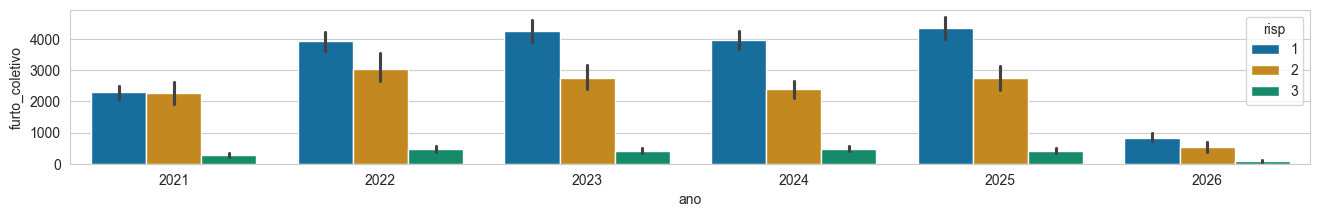

In [13]:
plt.figure(figsize=(16,2))
sns.barplot(data=df, x="ano", y="roubo_em_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)
plt.figure(figsize=(16,2))
sns.barplot(data=df, x="ano", y="furto_coletivo", hue="risp", estimator="sum", palette=qualitativepalette)

Notamos que na RISP 3, há menos ocorrência tanto de furto quanto de roubo em coletivo na maioria dos anos estudados. Como a base só pega o início de 2026, temos menor número total de ocorrências em 2026. 

CISP's com maior número de furtos:
[16 32 21 29 10  4  6 19 17  1 18 20 25 42 35]


C:\Users\marce\AppData\Local\Temp\ipykernel_9352\4121151056.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


cisp,furto_coletivo
16,2998
32,2317
21,1947
29,1656
10,1511
4,1235
6,1211
19,1165
17,1139
1,1053


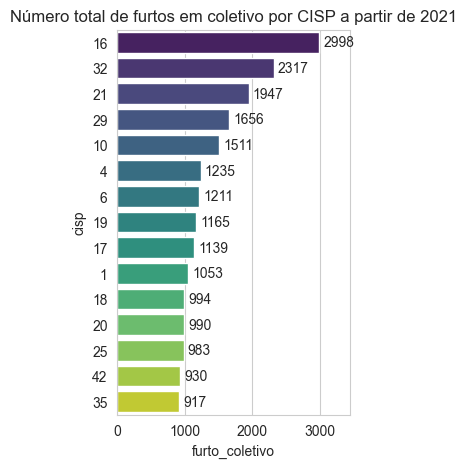

In [14]:
df_total = df.groupby('cisp')['furto_coletivo'].sum().reset_index()
df_total = df_total.sort_values(by='furto_coletivo', ascending=False).head(15)

print("CISP's com maior número de furtos:")
print((df_total['cisp'].unique()))

plt.figure(figsize=(3, 5)) 
ax = sns.barplot(
    data=df_total, 
    x="furto_coletivo",     
    y=df_total["cisp"].astype(str), 
    palette="viridis"       
)
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fmt='%d')
plt.xlim(0, df_total['furto_coletivo'].max() * 1.15)
plt.title("Número total de furtos em coletivo por CISP a partir de 2021")

tabela_furto = df_total.style.background_gradient(cmap='Reds') \
                    .format({'Total de Furtos': '{:,.0f}'}) \
                    .hide(axis='index')
tabela_furto

CISP's com maior número de roubos:
[64 21 39 59 17 29 54 32 34 25 18 53 60  6 16]


C:\Users\marce\AppData\Local\Temp\ipykernel_9352\1890047780.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


cisp,roubo_em_coletivo
64,2594
21,2117
39,1932
59,1732
17,1403
29,1198
54,1151
32,917
34,851
25,849


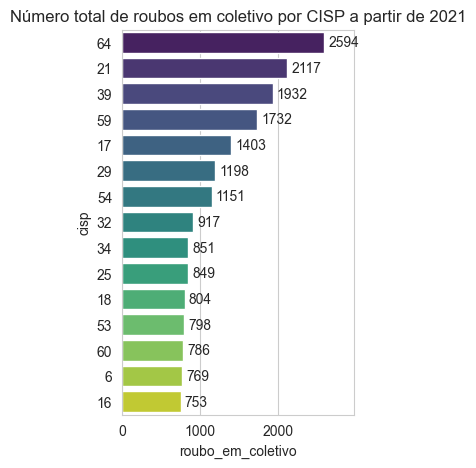

In [15]:
df_total = df.groupby('cisp')['roubo_em_coletivo'].sum().reset_index()
df_total = df_total.sort_values(by='roubo_em_coletivo', ascending=False).head(15)

print("CISP's com maior número de roubos:")
print((df_total['cisp'].unique()))

plt.figure(figsize=(3, 5)) 
ax = sns.barplot(
    data=df_total, 
    x="roubo_em_coletivo",     
    y=df_total["cisp"].astype(str), 
    palette="viridis"       
)
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10, fmt='%d')
plt.xlim(0, df_total['roubo_em_coletivo'].max() * 1.15)
plt.title("Número total de roubos em coletivo por CISP a partir de 2021")

tabela_roubo = df_total.style.background_gradient(cmap='Reds') \
                    .format({'Total de Furtos': '{:,.0f}'}) \
                    .hide(axis='index')
tabela_roubo

<Axes: xlabel='ano', ylabel='total_furtos'>

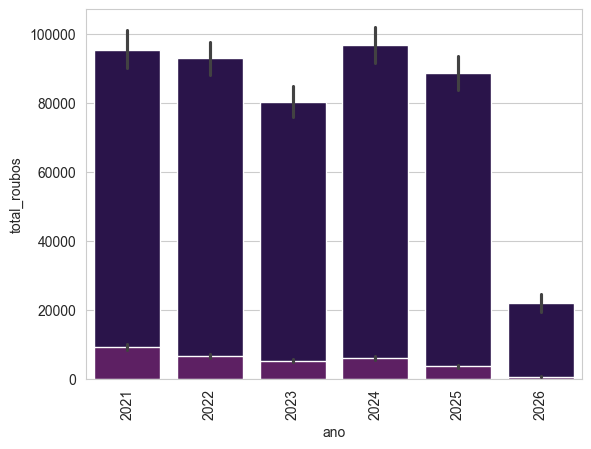

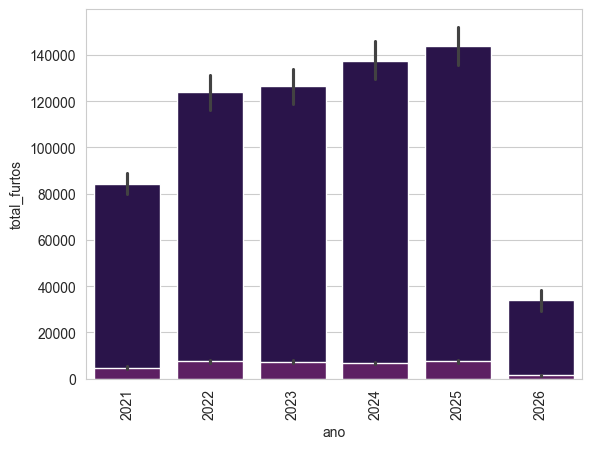

In [16]:
plt.figure()
plt.xticks(rotation=90)
sns.barplot(data=df, x="ano", y="total_roubos", estimator="sum")
sns.barplot(data=df, x="ano", y="roubo_em_coletivo", estimator="sum")
plt.figure()
plt.xticks(rotation=90)
sns.barplot(data=df, x="ano", y="total_furtos", estimator="sum")
sns.barplot(data=df, x="ano", y="furto_coletivo", estimator="sum")

    As Circunscrições Integradas de Segurança Pública - CISP, correspondem às áreas territoriais de atuação e responsabilidade conjunta das delegacias distritais da Secretaria de Estado de Polícia Civil (SEPOL) e das companhias integradas da Secretaria de Estado de Polícia Militar (SEPM). As CISP têm como princípio básico o conceito de que a responsabilidade pelo policiamento de uma subárea da companhia de Polícia Militar deverá coincidir com a circunscrição de uma delegacia de Polícia Civil. Nesse sentido, as CISP constituem a esfera de integração territorial, em nível operacional, das Companhias Integradas da SEPM com as Delegacias de Polícia da SEPOL. As CISP caracterizam, segundo este modelo de integração geográfica, a menor instância de apuração dos indicadores de criminalidade.

CISP's com maior número de furtos:
[16 32 21 29 10  4  6 19 17  1 18 20 25 42 35]

CISP's com maior número de roubos:
[64 21 39 59 17 29 54 32 34 25 18 53 60  6 16]

CISP's que aparecem em ambas listas: 
6 Catumbi, Cidade Nova, Estácio, Rio Comprido e Centro (parte)
16 Barra da Tijuca, Itanhangá, Joá
17 Caju, Mangueira, São Cristóvão e Vasco da Gama
18 Maracanã, Praça da Bandeira e Tijuca (parte)
21 Benfica, Bonsucesso, Higienópolis, Manguinhos, Maré e Ramos
25 Engenho Novo, Jacaré, Jacarezinho, Riachuelo, Rocha, Sampaio e
São Francisco Xavier
29 Cavalcanti, Engenheiro Leal, Madureira, Turiaçu, Vaz Lobo,
Oswaldo Cruz (parte), Cascadura e Quintino Bocaiúva
32 Anil, Cidade de Deus, Curicica, Gardênia Azul, Jacarepaguá e
Taquara 

Colocando os bairros correspondentes às CISPs como uma nova coluna:

In [17]:
cisps_bairros = {
    "1": "Centro (parte)",
    "4": "Centro (parte), Gamboa, Santo Cristo e Saúde",
    "5": "Centro (parte), Lapa e Paquetá",
    "6": "Catumbi, Cidade Nova, Estácio, Rio Comprido e Centro (parte)",
    "7": "Santa Teresa",
    "9": "Catete, Cosme Velho, Flamengo, Glória e Laranjeiras",
    "10": "Botafogo, Humaitá e Urca",
    "11": "Rocinha",
    "12": "Copacabana (parte) e Leme",
    "13": "Copacabana (parte)",
    "14": "Ipanema e Leblon",
    "15": "Gávea, Jardim Botânico, Lagoa, São Conrado e Vidigal",
    "16": "Barra da Tijuca, Itanhangá, Joá",
    "17": "Caju, Mangueira, São Cristóvão e Vasco da Gama",
    "18": "Maracanã, Praça da Bandeira e Tijuca (parte)",
    "19": "Alto da Boa Vista e Tijuca (parte)",
    "20": "Andaraí, Grajaú e Vila Isabel",
    "21": "Benfica, Bonsucesso, Higienópolis, Manguinhos, Maré e Ramos",
    "22": "Brás de Pina (parte), Olaria, Penha e Penha Circular (parte)",
    "23": "Cachambi, Méier (parte) e Todos os Santos (parte)",
    "24": "Abolição, Água Santa (parte), Encantado, Engenho de Dentro (parte), Pilares e Piedade",
    "25": "Engenho Novo, Jacaré, Jacarezinho, Riachuelo, Rocha, Sampaio e São Francisco Xavier",
    "26": "Água Santa (parte), Engenho de Dentro (parte), Lins de Vasconcelos e Todos os Santos",
    "27": "Colégio (parte), Irajá, Vicente de Carvalho, Vila Kosmos, Vila da Penha e Vista Alegre",
    "28": "Vila Valqueire, Praça Seca e Tanque (parte)",
    "29": "Cavalcante, Engenheiro Leal, Madureira, Turiaçu, Vaz Lobo, Oswaldo Cruz (parte), Cascadura e Quintino Bocaiúva",
    "30": "Bento Ribeiro, Campinho, Marechal Hermes e Oswaldo Cruz (parte)",
    "31": "Anchieta, Guadalupe, Parque Anchieta e Ricardo de Albuquerque",
    "32": "Anil, Cidade de Deus, Curicica, Gardenia Azul, Jacarepaguá e Taquara",
    "33": "Campo dos Afonsos, Deodoro, Jardim Sulacap, Magalhães Bastos, Realengo e Vila Militar",
    "34": "Bangu, Gericinó, Padre Miguel e Senador Camará",
    "35": "Campo Grande, Cosmos, Inhoaíba, Santíssimo e Senador Vasconcelos",
    "36": "Paciência e Santa Cruz",
    "37": "Bancários, Cacuia, Cidade Universitária, Cocotá, Freguesia, Galeão, Jardim Carioca, Jardim Guanabara, Moneró, Pitangueiras, Portuguesa, Praia da Bandeira, Ribeira, Tauá e Zumbi",
    "38": "Brás de Pina (parte), Cordovil, Jardim América, Parada de Lucas, Penha Circular (parte) e Vigário Geral",
    "39": "Acari, Barros Filho, Costa Barros, Parque Colúmbia e Pavuna",
    "40": "Coelho Neto, Colégio (parte), Honório Gurgel e Rocha Miranda",
    "41": "Freguesia (Jacarepaguá), Pechincha e Tanque (parte)",
    "42": "Recreio dos Bandeirantes, Barra de Guaratiba, Camorim, Grumari, Vargem Grande e Vargem Pequena",
    "43": "Guaratiba, Pedra de Guaratiba e Sepetiba",
    "44": "Del Castilho, Engenho da Rainha, Inhaúma, Maria da Graça e Tomás Coelho",
    "48": "Seropédica",
    "50": "Itaguaí e Ibituporanga",
    "51": "Paracambi",
    "52": "Centro (Nova Iguaçu)",
    "53": "Mesquita, Chatuba e Banco de Areia",
    "54": "Areia Branca, Jardim Redentor, Parque São José, Nova Aurora e Lote XV",
    "55": "Centro, Norte, Sul, Leste, Oeste e Nordeste (Queimados)",
    "56": "Comendador Soares, Cabuçu e Km32",
    "57": "Nilópolis e Olinda",
    "58": "Posse, Austin, Miguel Couto, Vila de Cava e Tinguá",
    "59": "Duque de Caxias (Centro)",
    "60": "Campos Elyseos",
    "61": "Xerém",
    "62": "Imbariê",
    "63": "Japeri, Engenheiro Pedreira, Marajoara, Pedra Lisa e Rio D' Ouro",
    "64": "São João de Meriti, Coelho da Rocha e São Mateus",
    "65": "Magé, Santo Aleixo e Suruí",
    "66": "Inhomirim e Guia de Copaíba",
    "67": "Guapimirim",
    "71": "Itaboraí, Cabuçu, Itambi, Porto das Caixas e Sambaetiba",
    "72": "São Gonçalo",
    "73": "Neves",
    "74": "Monjolo",
    "75": "Ipiíba e Sete Pontes",
    "76": "Centro, Ponta da Areia, Ilha da Conceição, São Lourenço, Fátima, Morro do Estado, Ingá, São Domingos, Gragoatá e Boa Viagem",
    "77": "Santa Rosa, Icaraí, Vital Brasil, Pé Pequeno, Viradouro e Cubango",
    "78": "Fonseca, Viçoso Jardim, Caramujo, Baldeador, Santa Bárbara, Tenente Jardim, Engenhoca, Santana e Barreto",
    "79": "Jurujuba, Charitas, São Francisco, Cachoeiras, Maceió, Largo da Batalha, Ititioca, Badu, Sapê, Matapaca, Vila Progresso, Muriqui, Maria Paula e Cantagalo",
    "81": "Itaipu, Camboinhas, Itacoatiara, Piratininga, Cafubá, Jacaré, Rio do Ouro, Engenho do Mato, Várzea das Moças e Jardim Imbuí",
    "82": "Maricá e Inoã",
    "88": "Barra do Piraí, Dorandia, Ipiabas, São José do Turvo e Vargem Alegre",
    "89": "Resende, Engenheiro Passos, Agulhas Negras, Pedra Selada e Fumaça",
    "90": "Antonio Rocha, Floriano, Nossa Senhora do Amparo, Rialto e Regiões Administrativas I a XIV (Barra Mansa)",
    "91": "Valença, Barão de Juparana, Conservatória, Parapeúna, Pentagna e Santa Isabel do Rio Preto",
    "92": "Rio das Flores, Manuel Duarte, Abarracamento e Taboas",
    "93": "Volta Redonda",
    "94": "Piraí, Arrozal, Monumento e Santanésia",
    "95": "Vassouras, Andrade Pinto, São Sebastião dos Ferreiros e Sebastião de Lacerda",
    "96": "Miguel Pereira, Governador Portela e Conrado",
    "97": "Paty do Alferes e Avelar",
    "98": "Mendes",
    "99": "Itatiaia",
    "100": "Porto Real / Quatis, Falcão e Ribeirão de São Joaquim",
    "101": "Pinheiral",
    "104": "São José do Vale do Rio Preto",
    "105": "Petrópolis e Cascatinha",
    "106": "Itaipava, Pedro do Rio e Posse",
    "107": "Paraíba do Sul, Werneck, Salutaris e Inconfidência",
    "108": "Areal / Três Rios e Bemposta / Comendador Levy Gasparian e Afonso Arinos",
    "109": "Sapucaia, Anta, Pião, Nossa Senhora Aparecida e Jamapara",
    "110": "Teresópolis, Vale do Bonsucesso e Vale do Paquequer",
    "111": "Sumidouro",
    "112": "Carmo, Córrego da Prata e Porto Velho do Cunha",
    "115": "Itaocara, Portela, Batatal, Laranjais, Jaguarembe e Estrada Nova",
    "118": "Araruama, Morro Grande e São Vicente de Paula",
    "119": "Rio Bonito e Boa Esperança",
    "120": "Silva Jardim, Aldeia Velha, Correntezas e Gaviões",
    "121": "Casimiro de Abreu, Professor Souza, Barra de São João e Rio Dourado",
    "122": "Conceição de Macabú e Macabuzinho",
    "123": "Centro, Cabiúnas, Barra de Macaé, Aeroporto e Imboassica",
    "124": "Saquarema, Bacaxá e Sampaio Correia",
    "125": "São Pedro da Aldeia",
    "126": "Cabo Frio e Tamoios",
    "127": "Armação dos Búzios",
    "128": "Rio das Ostras",
    "129": "Iguaba Grande",
    "130": "Quissamã / Centro, UB-S, Rodagem, Carapebus e Praia de Carapebus",
    "132": "Arraial do Cabo",
    "134": "Campos dos Goytacazes (1º, 2º e 4º Subdistritos, Ibitioca, Dores de Macabu, etc.)",
    "135": "Itaocara, Portela, Batatal, Laranjais, Jaguarembe e Estrada Nova",
    "136": "Aperibé / Santo Antônio de Pádua, Campelo, Paraoquena, Monte Alegre, etc.",
    "137": "Miracema, Venda das Flores e Paraíso do Tobias",
    "138": "Laje do Muriaé",
    "139": "Porciúncula, Purilândia e Santa Clara",
    "140": "Natividade, Ourania e Bom Jesus do Querendo / Varre-Sai",
    "141": "São Fidélis, Cambiasca, Colônia, Ipuca e Pureza",
    "142": "Cambuci, Três Irmãos, Funil, Monte Verde e São João do Paraíso",
    "143": "Itaperuna, Boaventura, Nossa Senhora da Penha, Itajara, Retiro do Muriaé, etc. / São José de Ubá",
    "144": "Bom Jesus de Itabapoana, Carabuçu, Calheiros, Pirapetinga, etc.",
    "145": "Barcelos, Atafona, São João da Barra, Grussaí, Cajueiro e Pipeiras",
    "146": "Campos dos Goytacazes (3º Subdistrito, Santa Maria, Morro do Coco, etc.)",
    "147": "São Francisco de Itabapoana, Maniva e Barra Seca",
    "148": "Italva / Cardoso Moreira e São Joaquim",
    "151": "Nova Friburgo, São Pedro da Serra, Lumiar, Amparo, Riograndina, etc.",
    "152": "Duas Barras e Monnerat",
    "153": "Cantagalo, Santa Rita da Floresta, Boa Sorte, Euclidelândia e São Sebastião da Paraíba",
    "154": "Cordeiro / Macuco",
    "155": "São Sebastião do Alto, Valão do Barro e Ipituna",
    "156": "Santa Maria Madalena, Doutor Loreti, Renascença, Santo Antônio do Imbé, etc.",
    "157": "Trajano de Moraes, Doutor Elias, Sodrelândia, Vila da Grama e Visconde de Imbé",
    "158": "Bom Jardim, Banquete, Barra Alegre e São José do Ribeirão",
    "159": "Cachoeiras de Macacu, Japuíba e Subaio",
    "165": "Mangaratiba, Conceição de Jacareí, Vila Muriqui, Itacuruça",
    "166": "Angra dos Reis, Jacuecanga, Cunhambebe, Mambucaba, Abraão e Praia de Araçatiba",
    "167": "Paraty, Paraty-Mirim e Tarituba",
    "168": "Rio Claro, Getulândia, Lídice, Passa Três e São João Marcos",
}

In [19]:
df['bairros'] = df['cisp'].astype(str).map(cisps_bairros)

In [ ]:
# Fiz o dataset dataframe_com_bairros utilizando o dicionário acima

with open("../datasets/dataframe_com_bairros.pkl","rb") as file:
    df = pickle.load(file)

Text(0.5, 1.0, 'Correlação com Roubo em Coletivo > 0.4')

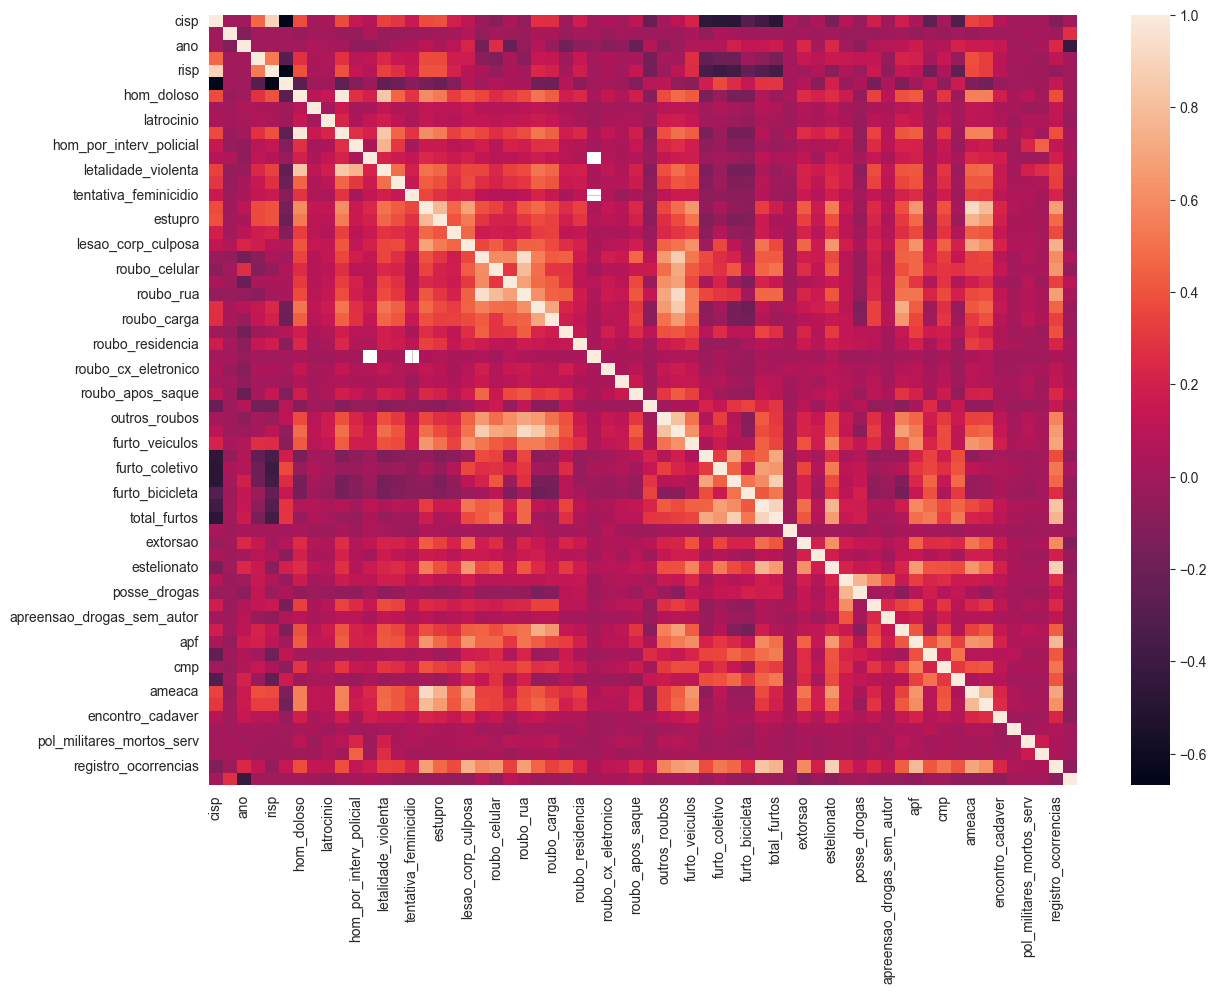

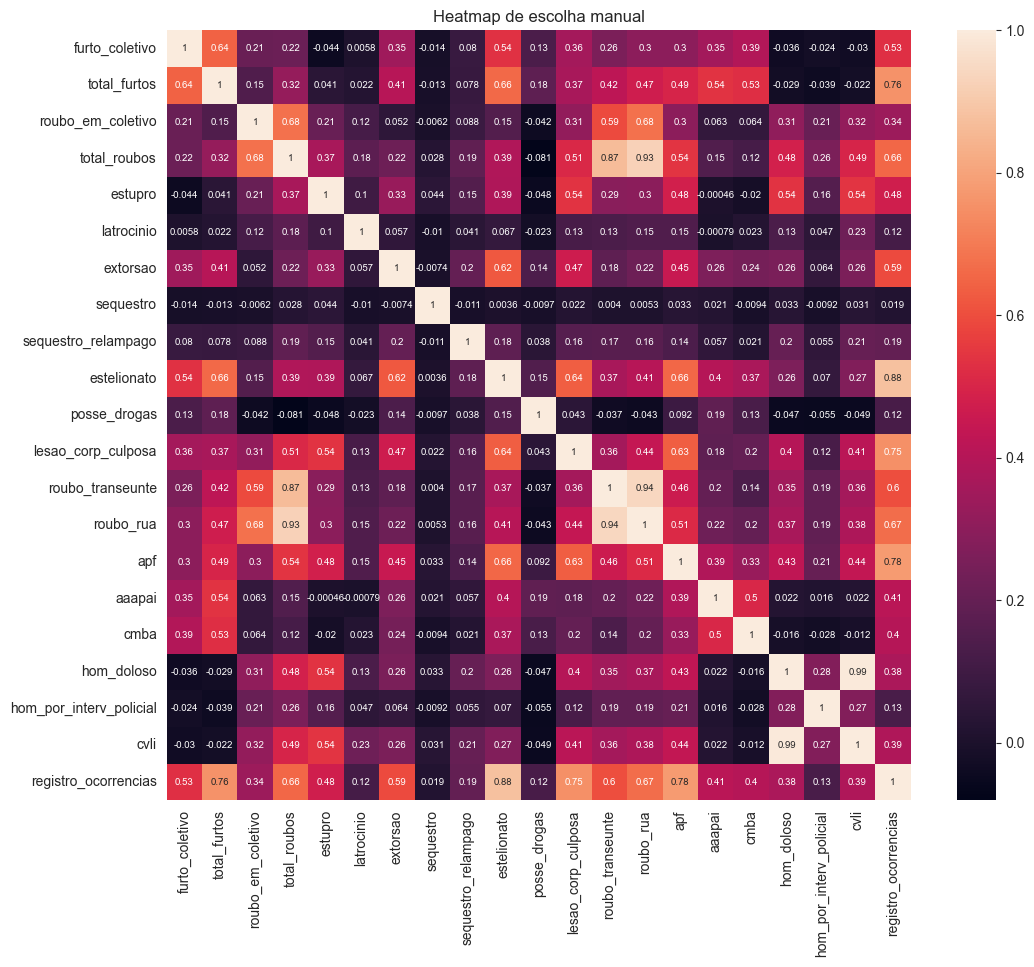

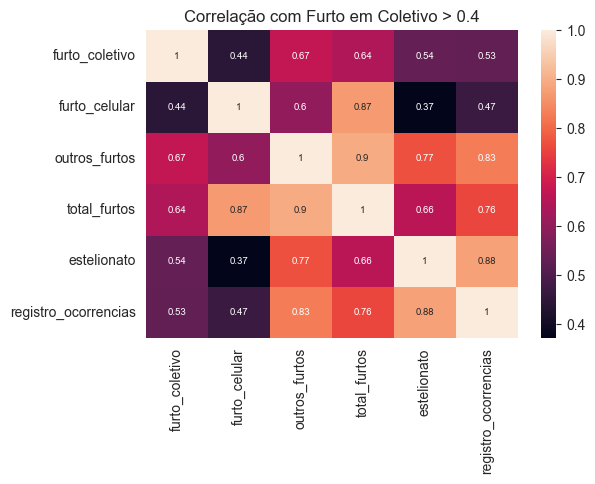

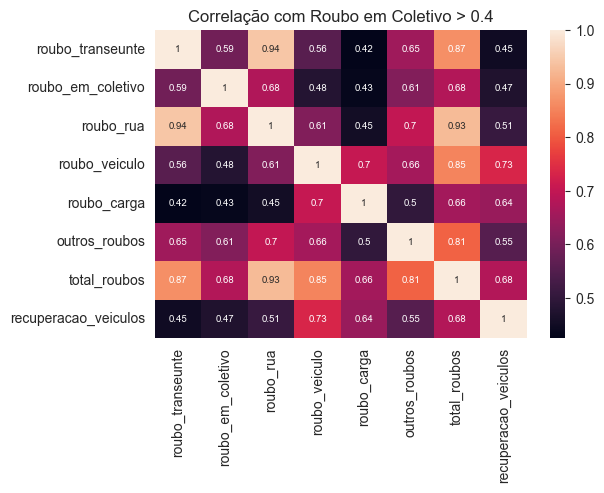

In [23]:
dfnumerical = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))
sns.heatmap(dfnumerical.corr())

dfheatmapmanual = df[["furto_coletivo", "total_furtos", 
                "roubo_em_coletivo", "total_roubos",
                "estupro",
                "latrocinio",
                "extorsao",
                "sequestro", "sequestro_relampago",
                "estelionato",
                "posse_drogas",
                "lesao_corp_culposa",
                "roubo_transeunte", "roubo_rua",
                "apf", "aaapai", "cmba", # não faço ideia do que seja isso, mas tem uma correlação forte com furto em coletivo
                "hom_doloso", "hom_por_interv_policial",
                "cvli",                  # não faço ideia do que seja isso, mas tem uma correlação forte com roubo em coletivo
                "registro_ocorrencias"]]


plt.figure(figsize=(12,10))
sns.heatmap(dfheatmapmanual.corr(), annot=True, annot_kws={"size": "x-small"}).set_title("Heatmap de escolha manual")

# Fazendo o heatmap somente dos valores que ficam acima de um dado valor (threshold)
threshold = 0.4

dfheatmapcorrfurto = dfnumerical[dfnumerical.corr()[dfnumerical.corr()["furto_coletivo"] > threshold]["furto_coletivo"].keys()].corr()
plt.figure(figsize=(6,4))
sns.heatmap(dfheatmapcorrfurto, annot=True, annot_kws={"size": "x-small"}).set_title(f"Correlação com Furto em Coletivo > {threshold}")

dfheatmapcorrroubo = dfnumerical[dfnumerical.corr()[dfnumerical.corr()["roubo_em_coletivo"] > threshold]["roubo_em_coletivo"].keys()].corr()
plt.figure(figsize=(6,4))
sns.heatmap(dfheatmapcorrroubo, annot=True, annot_kws={"size": "x-small"}).set_title(f"Correlação com Roubo em Coletivo > {threshold}")

C:\Users\marce\AppData\Local\Temp\ipykernel_5804\1688892770.py:1: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=df, x="furto_coletivo", y="roubo_em_coletivo", hue="risp", palette=qualitativepalette)


<Axes: xlabel='furto_coletivo', ylabel='roubo_em_coletivo'>

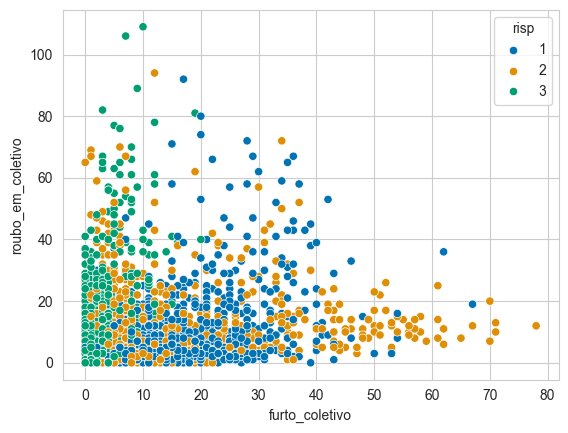

In [ ]:
sns.scatterplot(data=df, x="furto_coletivo", y="roubo_em_coletivo", hue="risp", palette=qualitativepalette)

C:\Users\marce\AppData\Local\Temp\ipykernel_5804\1204437406.py:1: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=df, x="furto_coletivo", y="outros_furtos", hue="risp", palette=qualitativepalette)


<Axes: xlabel='furto_coletivo', ylabel='outros_furtos'>

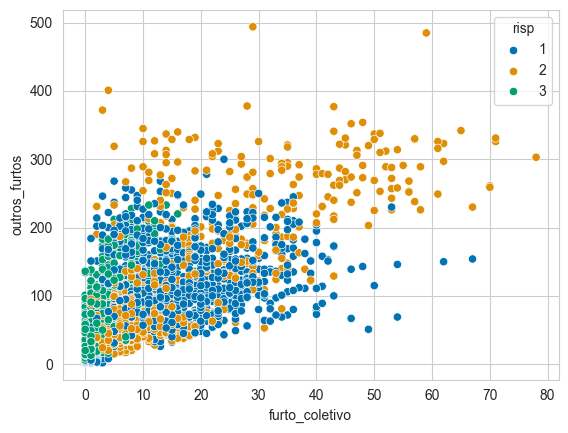

In [ ]:
sns.scatterplot(data=df, x="furto_coletivo", y="outros_furtos", hue="risp", palette=qualitativepalette)

C:\Users\marce\AppData\Local\Temp\ipykernel_5804\859059615.py:1: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.scatterplot(data=df, x="furto_coletivo", y="registro_ocorrencias", hue="risp", palette=qualitativepalette)


<Axes: xlabel='furto_coletivo', ylabel='registro_ocorrencias'>

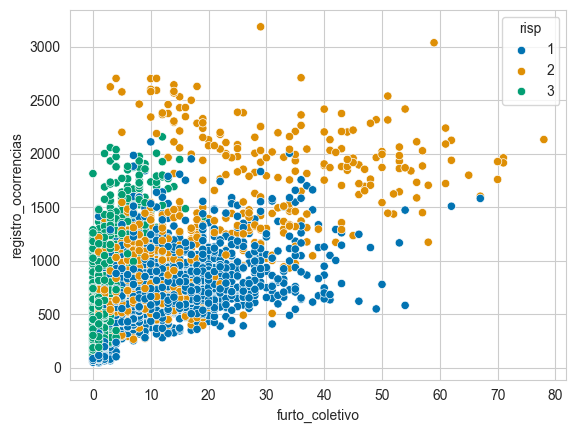

In [ ]:
sns.scatterplot(data=df, x="furto_coletivo", y="registro_ocorrencias", hue="risp", palette=qualitativepalette)

RISP 1

In [24]:
df_RISP1 = df[df['risp'] == 1]

In [51]:
df_RISP1['proporcao_furto'] = (df_RISP1['furto_coletivo'] / df_RISP1['total_furtos']) 

df_total = df_RISP1.groupby('aisp')['proporcao_furto'].sum().reset_index()
df_total = df_total.sort_values(by='proporcao_furto', ascending=False)
print("AISP's com maior proporção de furtos em coletivo:")
print((df_total['aisp'].unique()))
tabela_roubo = df_total.style.background_gradient(cmap='Reds') \
                    .format({'Proporção de Furtos': '{:,.0f}'}) \
                    .hide(axis='index')
tabela_roubo

AISP's com maior proporção de furtos em coletivo:
[ 3  6  5  4 23 16 22  2 19 17]


C:\Users\marce\AppData\Local\Temp\ipykernel_9352\362559375.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_RISP1['proporcao_furto'] = (df_RISP1['furto_coletivo'] / df_RISP1['total_furtos'])


aisp,proporcao_furto
3,23.127185
6,13.591889
5,12.946967
4,12.405760
23,10.680443
16,8.314264
22,6.987516
2,6.587890
19,3.565627
17,3.346372


In [52]:
df_RISP1['proporcao_roubo'] = (df_RISP1['roubo_em_coletivo'] / df_RISP1['total_roubos']) 

df_total = df_RISP1.groupby('aisp')['proporcao_roubo'].sum().reset_index()
df_total = df_total.sort_values(by='proporcao_roubo', ascending=False)
print("AISP's com maior proporção de roubos em coletivo:")
print((df_total['aisp'].unique()))
tabela_roubo = df_total.style.background_gradient(cmap='Reds') \
                    .format({'Proporção de Roubos': '{:,.0f}'}) \
                    .hide(axis='index')
tabela_roubo

AISP's com maior proporção de roubos em coletivo:
[ 4  5  3 23  6 22 16  2 19 17]


C:\Users\marce\AppData\Local\Temp\ipykernel_9352\2767748607.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_RISP1['proporcao_roubo'] = (df_RISP1['roubo_em_coletivo'] / df_RISP1['total_roubos'])


aisp,proporcao_roubo
4,20.255876
5,17.201157
3,16.490519
23,9.998201
6,9.074855
22,8.050938
16,7.014930
2,6.800886
19,3.675947
17,2.846938


Maior proporção de furtos em coletivo do total de furtos (23%) acontece na AISP 3 que corresponde à CISPs 23, 44, 25, 26, 24, áreas da Zona Norte do Rio de Janeiro, a região de atuação centraliza-se na Grande Méier, frequentemente associada a pontos como o Norte Shopping.

Para o segundo lugar, vemos um decaimento bem grande, na AISP 6, que corresponde a área da grande Tijuca, 13.5% dos furtos totais são no coletivo.

E em terceiro lugar, sendo 12% dos furtos em coletivos, as regiões do Centro do Rio e limites de São Cristóvão (AISP 5 e 4). 

Maior proporção de roubos em coletivo do total de furtos (20.3%) acontece na AISP 4 que corresponde à CISPs 6, 17, áreas entre São Cristóvão/Estácio.

Para o segundo lugar, na AISP 5, região próxima da AISP 4 com a maior proporção, que corresponde a área Central do Rio, 17% dos roubos totais são no coletivo.

E em terceiro lugar, sendo 16% dos roubos em coletivos, acontece na AISP 3 que corresponde à CISPs 23, 44, 25, 26, 24, áreas da Zona Norte do Rio de Janeiro, a região de atuação centraliza-se na Grande Méier, frequentemente associada a pontos como o Norte Shopping.

Concluímos que nas AISPs 3, 4 e 5, há um grande risco de violência, essas áreas abrangem do grande Méier até o Centro do Rio.

Maiores estatísticas:
A AISP 4 (São Cristóvão/Estácio) apresenta a maior concentração relativa de roubos em coletivo (20.3%), indicando um uso mais frequente de violência ou ameaça nessas conexões geográficas.
A AISP 3 (Grande Méier) é o centro dos furtos em coletivo (23%), sugerindo que locais de grande aglomeração e fluxo comercial, como o entorno do Norte Shopping ou engenhão favorecem ações de oportunidade sem o uso de força direta.

## 